Dataset Information

This dataset contains information on default payments, demographic factors, credit data, history of payment, and bill statements of credit card clients in Taiwan from April 2005 to September 2005.

There are 25 variables:

    ID: ID of each client
    LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit)
    SEX: Gender (1=male, 2=female)
    EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)
    MARRIAGE: Marital status (1=married, 2=single, 3=others)
    AGE: Age in years
    PAY_1: Repayment status in September, 2005 (-2: No consumption; -1: Paid in full; 0: The use of revolving credit; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.)
    PAY_2: Repayment status in August, 2005 (scale same as above)
    PAY_3: Repayment status in July, 2005 (scale same as above)
    PAY_4: Repayment status in June, 2005 (scale same as above)
    PAY_5: Repayment status in May, 2005 (scale same as above)
    PAY_6: Repayment status in April, 2005 (scale same as above)
    BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)
    BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)
    BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)
    BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)
    BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)
    BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)
    PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)
    PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)
    PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)
    PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)
    PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)
    PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)
    default.payment.next.month: Default payment (1=yes, 0=no)

Link to Kaggle - https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset/data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# df = pd.read_csv("C:\\Users\\matve\\OneDrive\\Рабочий стол\\Программирование\\Kaggle\\Default of Credit Card Clients Dataset\\UCI_Credit_Card.csv").drop(columns=['ID'])
df = pd.read_csv("C:\\Users\\ZhukovskyMD\\Desktop\\UCI_Credit_Card.csv").drop(columns=['ID'])
df = df.rename(columns={'PAY_0' : 'PAY_1', 'default.payment.next.month' : 'default'})
df.sample(7)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
6057,230000.0,1,1,1,44,-1,-1,-1,-1,0,...,1630.0,815.0,815.0,815.0,815.0,1630.0,0.0,815.0,629.0,0
7387,50000.0,2,3,2,55,0,0,0,0,0,...,20127.0,18988.0,19942.0,6000.0,2044.0,3150.0,1000.0,3000.0,905.0,0
10419,30000.0,1,2,1,38,1,2,2,2,0,...,13344.0,13972.0,18735.0,0.0,5000.0,0.0,1000.0,5000.0,0.0,0
9051,70000.0,2,2,2,25,0,0,0,0,0,...,44590.0,45890.0,47126.0,2294.0,2100.0,1600.0,2000.0,2000.0,1750.0,1
25232,50000.0,2,2,2,24,-1,-1,-1,-1,0,...,6561.0,5091.0,353.0,1572.0,1572.0,6561.0,102.0,353.0,27000.0,0
19599,290000.0,2,1,2,36,0,0,0,0,0,...,55293.0,54738.0,55435.0,2514.0,3007.0,2004.0,2101.0,2503.0,2503.0,0
22121,170000.0,2,2,2,29,-1,-1,-1,-1,-1,...,1042.0,1577.0,1574.0,1359.0,886.0,1051.0,1577.0,1574.0,287.0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LIMIT_BAL  30000 non-null  float64
 1   SEX        30000 non-null  int64  
 2   EDUCATION  30000 non-null  int64  
 3   MARRIAGE   30000 non-null  int64  
 4   AGE        30000 non-null  int64  
 5   PAY_1      30000 non-null  int64  
 6   PAY_2      30000 non-null  int64  
 7   PAY_3      30000 non-null  int64  
 8   PAY_4      30000 non-null  int64  
 9   PAY_5      30000 non-null  int64  
 10  PAY_6      30000 non-null  int64  
 11  BILL_AMT1  30000 non-null  float64
 12  BILL_AMT2  30000 non-null  float64
 13  BILL_AMT3  30000 non-null  float64
 14  BILL_AMT4  30000 non-null  float64
 15  BILL_AMT5  30000 non-null  float64
 16  BILL_AMT6  30000 non-null  float64
 17  PAY_AMT1   30000 non-null  float64
 18  PAY_AMT2   30000 non-null  float64
 19  PAY_AMT3   30000 non-null  float64
 20  PAY_AMT4   30000 

In [4]:
print(df.duplicated().sum())

# Removing duplicates
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

35
0


**EDA**

In [5]:
df.sample(5)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
26511,100000.0,2,3,1,55,2,3,2,-1,3,...,1623.0,1470.0,930.0,0.0,0.0,1623.0,0.0,0.0,780.0,0
17101,30000.0,2,2,1,25,1,2,0,0,0,...,30524.0,28915.0,29524.0,0.0,1831.0,1449.0,1100.0,1051.0,1281.0,1
8652,360000.0,2,2,2,25,-1,-1,-1,-1,-1,...,991.0,4632.0,2014.0,4098.0,6401.0,997.0,4641.0,2014.0,5.0,0
8929,10000.0,1,2,2,29,2,2,2,2,3,...,9089.0,8658.0,8372.0,2600.0,600.0,895.0,0.0,0.0,764.0,1
20084,500000.0,2,2,1,31,0,0,0,0,0,...,316739.0,167616.0,364940.0,15210.0,15022.0,20121.0,5925.0,35069.0,35110.0,0


In [6]:
print(df['default'].value_counts(normalize=True)) # big class imbalance

default
0    0.778742
1    0.221258
Name: proportion, dtype: float64


In [7]:
# Looking at zeros in 'EDUCATION' and 'MARRIAGE' since they are not stated in the description
display(df['MARRIAGE'].value_counts())

MARRIAGE
2    15945
1    13643
3      323
0       54
Name: count, dtype: int64

In [8]:
display(df[df['MARRIAGE'] == 0].sample(5))
print(df[df['MARRIAGE'] == 0]['default'].sum(), df[df['MARRIAGE'] == 0].shape[0])
display(df[df['EDUCATION'] == 0].sample(5))
print(df[df['EDUCATION'] == 0]['default'].sum(), df[df['EDUCATION'] == 0].shape[0])

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
12050,80000.0,2,3,0,37,-2,-2,-2,-2,-2,...,3882.0,4785.0,1000.0,3087.0,5215.0,3882.0,4785.0,1968.0,0.0,0
3056,200000.0,1,3,0,36,-2,-2,-2,-2,-2,...,41359.0,9140.0,0.0,89187.0,14178.0,41359.0,9140.0,0.0,0.0,0
28602,200000.0,2,3,0,37,1,-1,-1,-1,-1,...,4000.0,22800.0,5716.0,35000.0,5000.0,4000.0,22800.0,5716.0,0.0,0
25308,170000.0,2,2,0,24,-1,0,0,0,0,...,35458.0,30143.0,42215.0,2000.0,2165.0,2285.0,500.0,28500.0,2000.0,0
23360,240000.0,2,3,0,37,-1,-1,-1,-1,0,...,6229.0,15829.0,20785.0,1823.0,1788.0,6229.0,10000.0,10000.0,5640.0,0


5 54


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
24137,150000.0,1,0,2,28,0,0,0,0,-1,...,9864.0,3957.0,2205.0,18056.0,4065.0,1058.0,3976.0,2216.0,0.0,0
5945,270000.0,1,0,2,39,1,-1,-1,-1,-1,...,18607.0,0.0,0.0,10193.0,70213.0,19008.0,399.0,0.0,0.0,0
17414,230000.0,2,0,2,47,-1,-1,-1,2,-1,...,255.0,5425.0,4838.0,5743.0,1598.0,0.0,5425.0,4838.0,3840.0,0
15107,210000.0,1,0,2,45,-2,-2,-2,-2,-2,...,788.0,3499.0,3372.0,5854.0,1032.0,788.0,3565.0,3372.0,15381.0,0
19920,50000.0,2,0,1,40,0,0,0,0,0,...,47647.0,40500.0,41921.0,2229.0,2298.0,2100.0,2500.0,1921.0,8432.0,0


0 14


In [9]:
zero_group = df[(df['EDUCATION'] == 0) | (df['MARRIAGE'] == 0)].reset_index(drop=True)
non_zero_group = df[~((df['EDUCATION'] == 0) | (df['MARRIAGE'] == 0))].reset_index(drop=True)
print(f"Default rate in 'zero' group = {zero_group['default'].mean():.5f}, total group size = {zero_group.shape[0]}")
print(f"Default rate in 'non-zero' group = {non_zero_group['default'].mean():.5f}, total group size = {non_zero_group.shape[0]}")

# Dropping out 'zero' group will slightly increase the default rate and hence will decrese the class imbalance
df = non_zero_group

Default rate in 'zero' group = 0.07353, total group size = 68
Default rate in 'non-zero' group = 0.22159, total group size = 29897


In [10]:
display(df.groupby(['SEX']).agg({'default' : 'mean',
                               'LIMIT_BAL' : 'mean'}).sort_values(by='default', ascending=False))
display(df.groupby(['MARRIAGE']).agg({'default' : 'mean',
                               'LIMIT_BAL' : 'mean'}).sort_values(by='default', ascending=False))
display(df.groupby(['EDUCATION']).agg({'default' : 'mean',
                               'LIMIT_BAL' : 'mean'}).sort_values(by='default', ascending=False))

,default,LIMIT_BAL
SEX,,
1,0.241900,163441.923726
2,0.208257,170133.887503


,default,LIMIT_BAL
MARRIAGE,,
3,0.260062,98080.495356
1,0.234695,182154.996701
2,0.209602,156328.062755


,default,LIMIT_BAL
EDUCATION,,
3,0.253131,126626.499692
2,0.237422,147038.178834
1,0.192442,212910.313477
6,0.156863,148235.294118
5,0.064286,168164.285714
4,0.056911,220894.308943


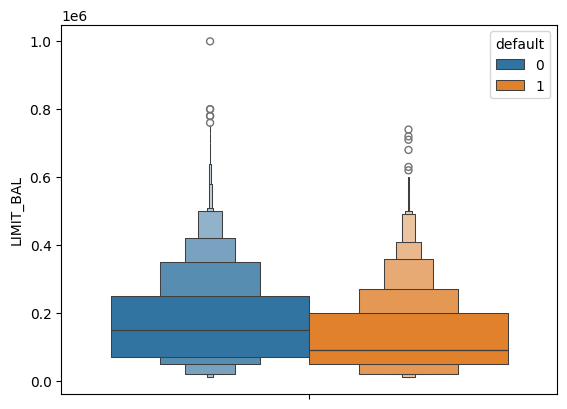

In [11]:
sns.boxenplot(y='LIMIT_BAL', data=df, hue='default')
plt.show()

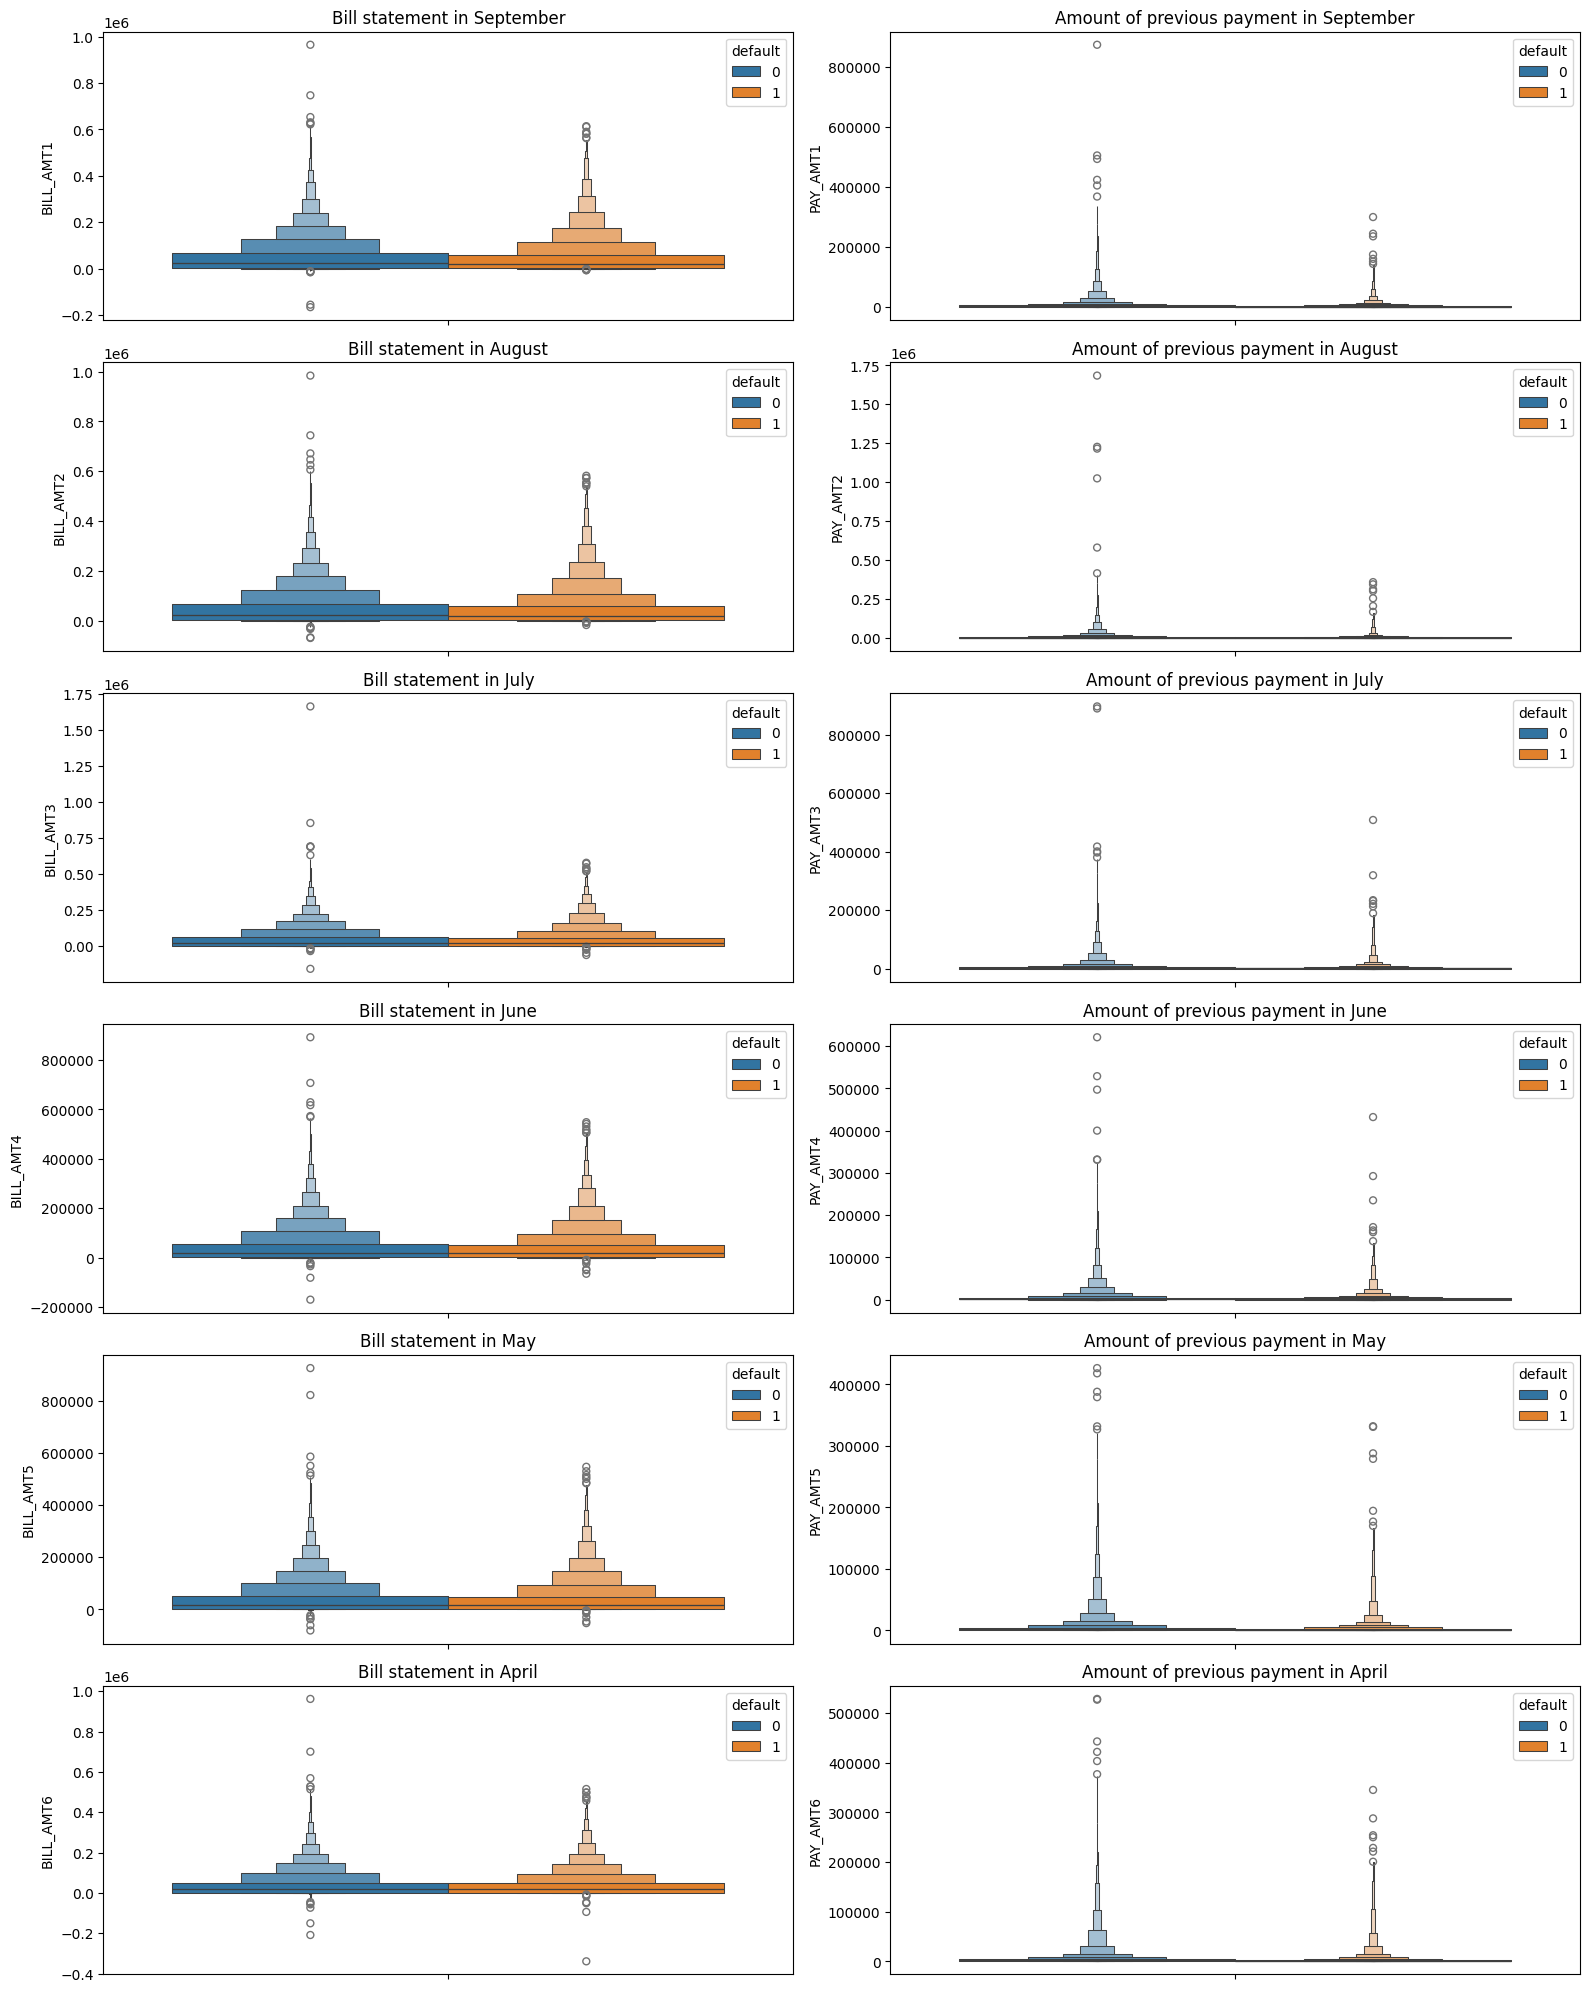

In [12]:
months = ['September', 'August', 'July', 'June', 'May', 'April']
bill_atm = list(df.columns[11:17])
pay_atm = list(df.columns[17:-1])

fig, axes = plt.subplots(6, 2, figsize=(16,20))
for i in range(6):
    sns.boxenplot(y=bill_atm[i], hue='default', data=df, ax=axes[i, 0])
    axes[i, 0].set_title(f'Bill statement in {months[i]}')
    sns.boxenplot(y=pay_atm[i], hue='default', data=df, ax=axes[i, 1])
    axes[i, 1].set_title(f'Amount of previous payment in {months[i]}')
plt.tight_layout()
plt.show()


In [13]:
pay = df.columns[5:11]
for column in pay:
    print(f"column - {column}, amount of errors - {df[(df[column] < -2) | (df[column] > 9)].shape[0]}")

column - PAY_1, amount of errors - 0
column - PAY_2, amount of errors - 0
column - PAY_3, amount of errors - 0
column - PAY_4, amount of errors - 0
column - PAY_5, amount of errors - 0
column - PAY_6, amount of errors - 0


No errors in 'PAY' columns, but there are still negative observations in 'BILL_ATM' column, which should be removed

In [14]:
index_to_drop = []
for col_bill, col_pay in zip(bill_atm, pay_atm):
    index_out = df[(df[col_bill] < 0) | ((df[col_pay] < 0))].index
    index_to_drop.extend(list(index_out))
print(f"Amount of erros in the dataframe - {len(set(index_to_drop))}")
df.drop(index=index_to_drop, inplace=True)
df.reset_index(drop=True, inplace=True)

Amount of erros in the dataframe - 1929


In [15]:
# Outliers
quantiles_bill = []
quantiles_pay_atm = []
outliers_drop = []
for col_bill, col_pay in zip(bill_atm, pay_atm):
    bill_quant_99 = np.quantile(df[col_bill], q=0.99)
    pay_atm_quant_99 = np.quantile(df[col_pay], q=0.99)
    quantiles_bill.append(bill_quant_99)
    quantiles_bill.append(pay_atm_quant_99)
    outliers_drop.extend(list(df[(df[col_bill] > bill_quant_99) | (df[col_pay] > pay_atm_quant_99)].index))
print(f'Amount of outliers = {len(set(outliers_drop))}')
df.drop(index=outliers_drop, inplace=True)
df.reset_index(drop=True, inplace=True)

Amount of outliers = 1774


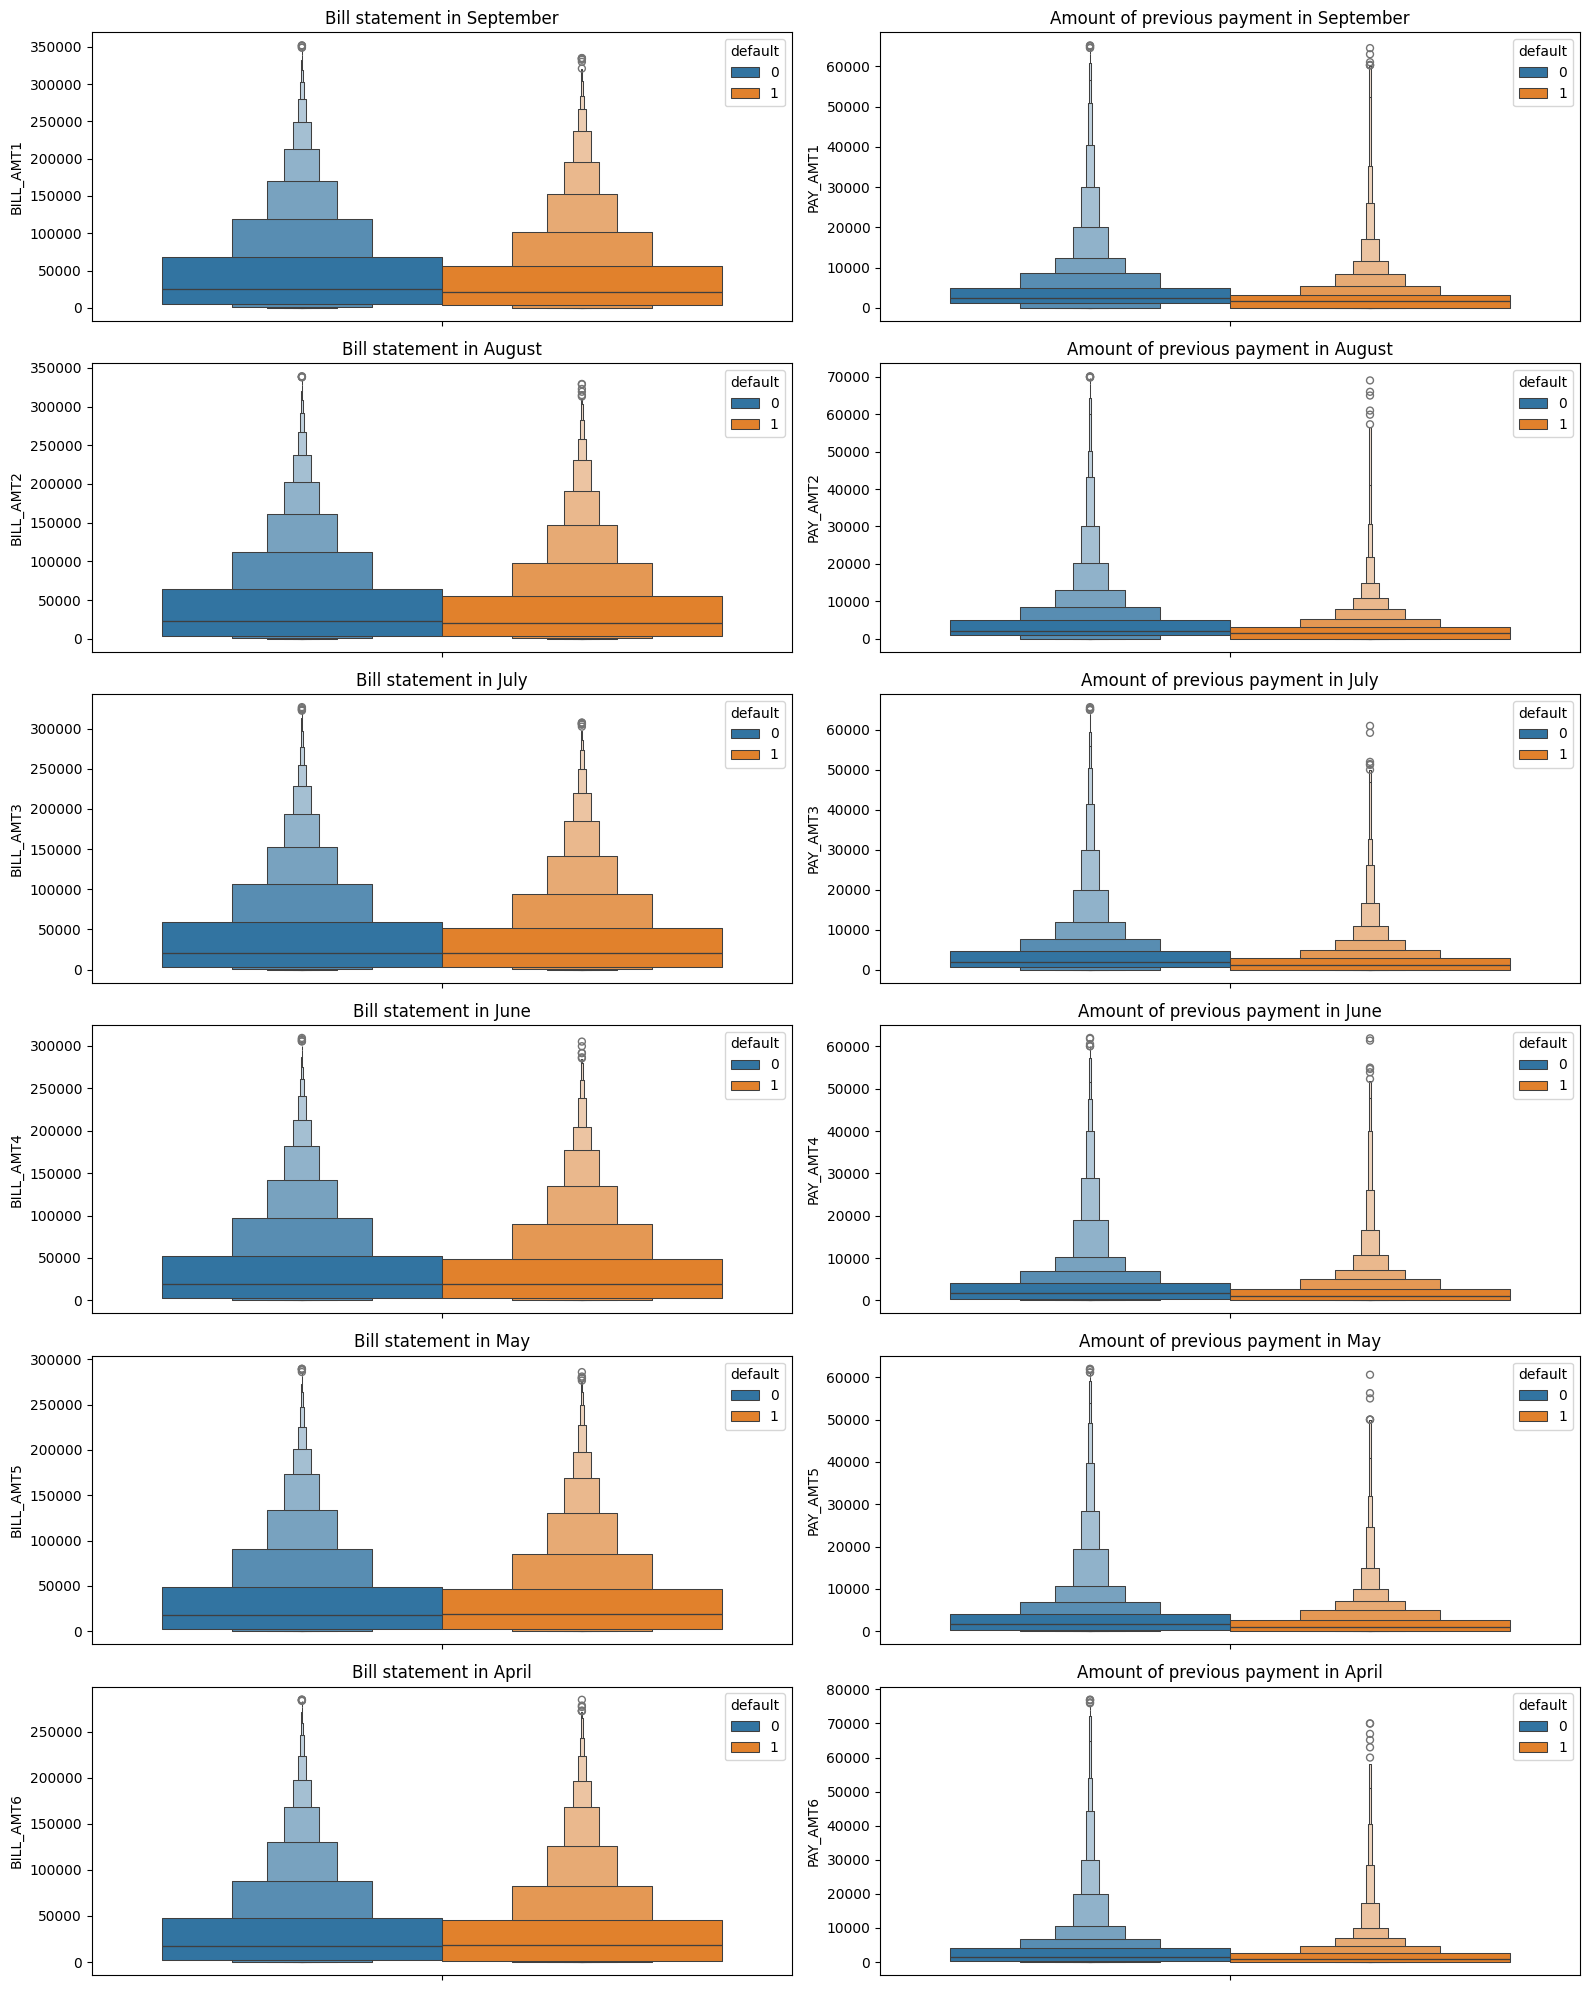

In [16]:
fig, axes = plt.subplots(6, 2, figsize=(16,20))
for i in range(6):
    sns.boxenplot(y=bill_atm[i], hue='default', data=df, ax=axes[i, 0])
    axes[i, 0].set_title(f'Bill statement in {months[i]}')
    sns.boxenplot(y=pay_atm[i], hue='default', data=df, ax=axes[i, 1])
    axes[i, 1].set_title(f'Amount of previous payment in {months[i]}')
plt.tight_layout()
plt.show()

In [17]:
# Feature engineering
df['ANY_DELAY'] = (df[pay] > 0).any(axis=1).astype('int')
df['MAX_DELAY'] = df[pay].max(axis=1)
df['DELAY_STD'] = df[pay].std(axis=1)
df['UNPAID'] = df[bill_atm].sum(axis=1) - df[pay_atm].sum(axis=1)
df['PAY_AMT_RATIO_LAST'] = df['PAY_AMT1'] / (df['BILL_AMT1']+1e-6)
df['PAY_AMT_MEAN_RATIO'] = df[[f'PAY_AMT{i}' for i in range(1,7)]].mean(axis=1) / (df[[f'BILL_AMT{i}' for i in range(1,7)]].mean(axis=1)+1e-6) 
df['UTILIZATION_1'] = df['BILL_AMT1'] / df['LIMIT_BAL']
df.sample(5)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT5,PAY_AMT6,default,ANY_DELAY,MAX_DELAY,DELAY_STD,UNPAID,PAY_AMT_RATIO_LAST,PAY_AMT_MEAN_RATIO,UTILIZATION_1
3905,20000.0,1,1,2,24,-1,-1,-1,-1,-1,...,1624.0,3800.0,0,0,-1,0.0,-556.0,1.185662,1.019488,0.190400
2270,490000.0,1,3,1,51,-1,-1,-1,-1,-1,...,1.0,1.0,1,0,-1,0.0,147.0,0.969152,0.914485,0.000794
4643,20000.0,2,2,1,22,0,0,0,0,0,...,1000.0,1000.0,0,0,0,0.0,111903.0,0.075778,0.052497,0.923750
20805,50000.0,2,1,2,51,0,0,0,0,0,...,1314.0,1159.0,0,0,0,0.0,265472.0,0.064705,0.043068,0.865460
13996,50000.0,2,2,1,34,0,0,0,0,0,...,1300.0,1238.0,0,0,0,0.0,251406.0,0.039206,0.039034,1.020240


In [18]:
df.groupby('default')['MAX_DELAY'].mean()

default
0    0.240079
1    1.329262
Name: MAX_DELAY, dtype: float64

In [19]:
df_with_dummies = pd.get_dummies(data=df, columns=['SEX', 'MARRIAGE'], drop_first=True, dtype='int')
df_with_dummies = df_with_dummies.rename(columns={'SEX_2' : 'SEX_female', 'MARRIAGE_2' : 'MARRIAGE_single', 'MARRIAGE_3' : 'MARRIAGE_other'})
df_with_dummies.head()

,LIMIT_BAL,EDUCATION,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,...,ANY_DELAY,MAX_DELAY,DELAY_STD,UNPAID,PAY_AMT_RATIO_LAST,PAY_AMT_MEAN_RATIO,UTILIZATION_1,SEX_female,MARRIAGE_single,MARRIAGE_other
0,20000.0,2,24,2,2,-1,-1,-2,-2,3913.0,...,1,2,1.861899,7015.0,0.000000,0.089434,0.195650,1,0,0
1,120000.0,2,26,-1,2,0,0,0,2,2682.0,...,1,2,1.224745,12077.0,0.000000,0.292791,0.022350,1,1,0
2,90000.0,2,34,0,0,0,0,0,0,29239.0,...,0,0,0.000000,90635.0,0.051917,0.108388,0.324878,1,1,0
3,50000.0,2,37,0,0,0,0,0,0,46990.0,...,0,0,0.000000,222946.0,0.042562,0.036259,0.939800,1,0,0
4,50000.0,2,57,-1,0,-1,0,0,0,8617.0,...,0,0,0.516398,50290.0,0.232099,0.540054,0.172340,0,0,0


In [20]:
df_with_dummies['YOUNG'] = np.where(df_with_dummies['AGE'] <= 30, 1, 0)
df_with_dummies['ADULT'] = np.where((df_with_dummies['AGE'] > 30) & (df_with_dummies['AGE'] <= 60), 1, 0)
df_with_dummies['PENSIONER'] = np.where(df_with_dummies['AGE'] > 60, 1, 0)
df_with_dummies.drop(columns=['AGE'], inplace=True)
df_with_dummies.head()

,LIMIT_BAL,EDUCATION,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,UNPAID,PAY_AMT_RATIO_LAST,PAY_AMT_MEAN_RATIO,UTILIZATION_1,SEX_female,MARRIAGE_single,MARRIAGE_other,YOUNG,ADULT,PENSIONER
0,20000.0,2,2,2,-1,-1,-2,-2,3913.0,3102.0,...,7015.0,0.000000,0.089434,0.195650,1,0,0,1,0,0
1,120000.0,2,-1,2,0,0,0,2,2682.0,1725.0,...,12077.0,0.000000,0.292791,0.022350,1,1,0,1,0,0
2,90000.0,2,0,0,0,0,0,0,29239.0,14027.0,...,90635.0,0.051917,0.108388,0.324878,1,1,0,0,1,0
3,50000.0,2,0,0,0,0,0,0,46990.0,48233.0,...,222946.0,0.042562,0.036259,0.939800,1,0,0,0,1,0
4,50000.0,2,-1,0,-1,0,0,0,8617.0,5670.0,...,50290.0,0.232099,0.540054,0.172340,0,0,0,0,1,0


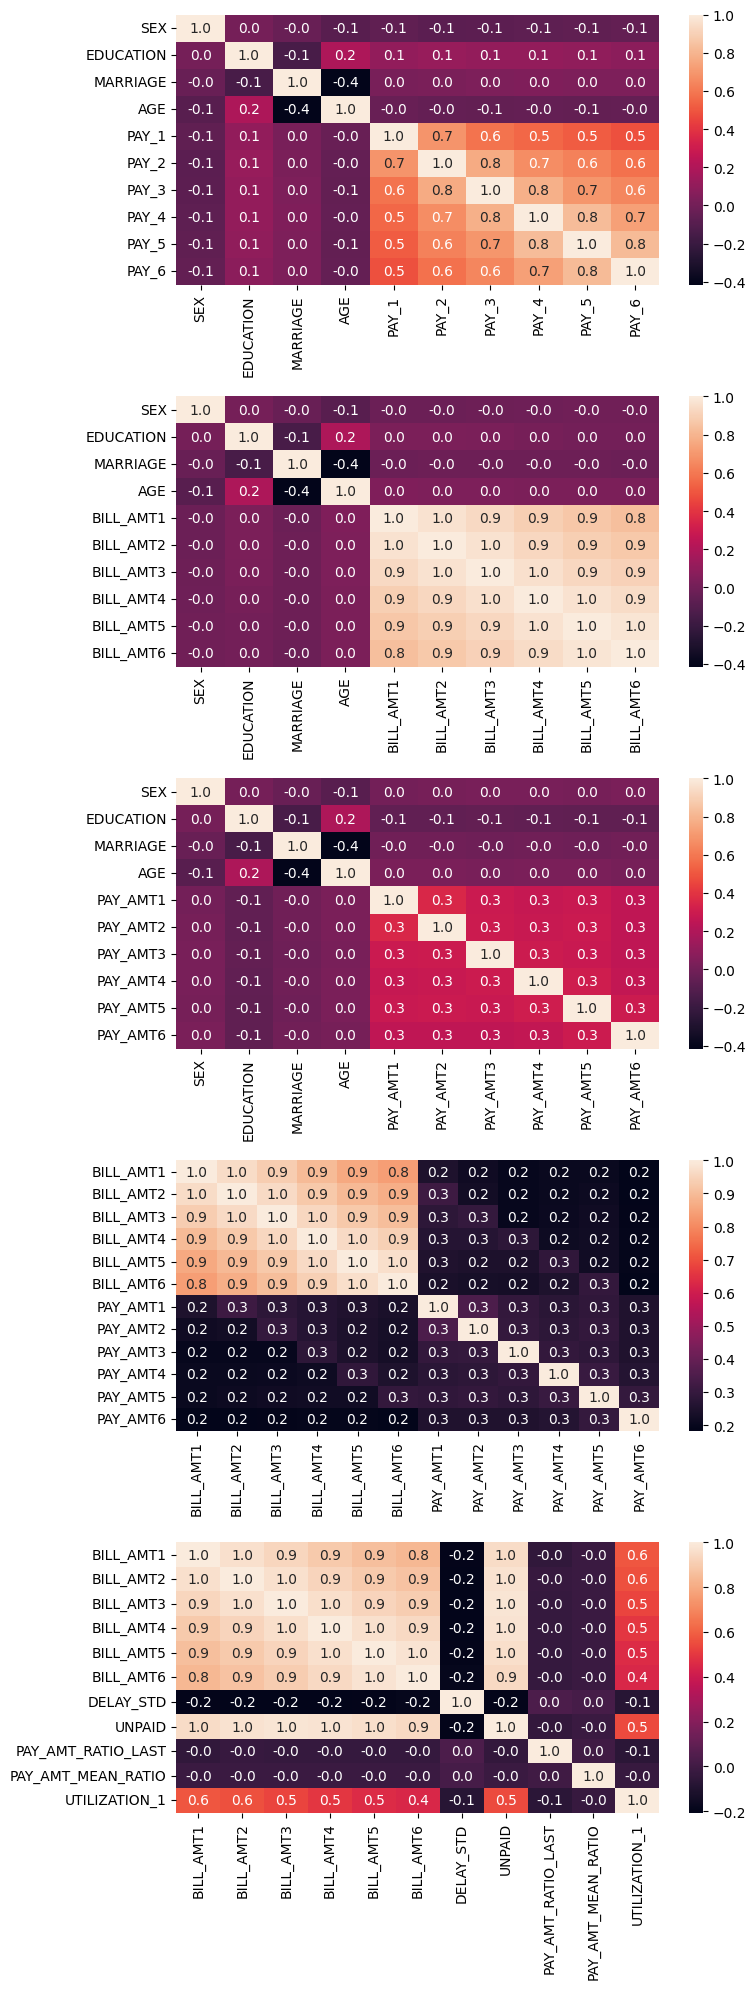

In [21]:
fig, axes = plt.subplots(5, 1, figsize=(8, 20))
sns.heatmap(df[['SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']].corr(), annot=True, fmt='.1f', ax=axes[0])
sns.heatmap(df[['SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].corr(), annot=True, fmt='.1f', ax=axes[1])
sns.heatmap(df[['SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].corr(), annot=True, fmt='.1f', ax=axes[2])
sns.heatmap(df[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].corr(), annot=True, fmt='.1f', ax=axes[3])
sns.heatmap(df[bill_atm + list(df.columns[-5:])].corr(), annot=True, fmt='.1f', ax=axes[4])
plt.tight_layout()
plt.show()

**MODELLING**

In [22]:
# Splitting for train and test parts
from sklearn.model_selection import train_test_split
X = df_with_dummies.drop(columns=['default'])
y = df_with_dummies['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

In [23]:
# Target encoding
from sklearn.preprocessing import TargetEncoder
target_encoder = TargetEncoder(smooth='auto')
education_train = np.array(X_train['EDUCATION']).reshape(-1, 1)
education_test = np.array(X_test['EDUCATION']).reshape(-1, 1)
educ_endcoded_train = target_encoder.fit_transform(education_train, y_train)
educ_endcoded_test = target_encoder.transform(education_test)
X_train['EDUCATION'] = educ_endcoded_train
X_test['EDUCATION'] = educ_endcoded_test

Even before moving to EDA, I will check a very primitive idea: if a person has a huge delay in payments, he will probably default

In [24]:
defaulters = train_df[train_df['default'] == 1]
non_defaulters = train_df[train_df['default'] == 0]

display(defaulters[['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default']])
display(non_defaulters[['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default']])

,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,default
14803,2,0,0,0,0,0,1
21282,2,2,2,2,2,2,1
6764,2,0,0,0,0,0,1
6587,-1,2,2,2,0,0,1
15023,2,2,2,0,0,0,1
...,...,...,...,...,...,...,...
16739,3,2,0,0,0,3,1
3634,0,0,0,0,0,0,1
12590,1,2,0,0,0,0,1
22270,-1,-1,-1,-1,-2,-1,1


,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,default
25701,0,0,0,0,0,0,0
7422,0,0,0,0,0,0,0
11259,0,0,0,0,0,0,0
17512,0,0,0,0,0,0,0
13416,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...
364,0,0,0,0,0,0,0
3939,-2,-2,-2,-2,-2,-2,0
18167,-1,-1,-1,0,0,0,0
20166,-1,-1,2,0,-1,0,0


In [25]:
def prediction_maker(thr):
    prediction = []
    for i in range(0, len(test_df)):
        if abs(test_df.iloc[i, 2:8].sum()) >= thr:
            prediction.append(1)
        else:
            prediction.append(0)
    return prediction

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
accuracy = []
f1 = []
recall = []
precision = []
roc_auc = []
for thr in list(range(1, 20)):
    prediction = prediction_maker(thr)
    accuracy.append(accuracy_score(test_df['default'].values, prediction))
    recall.append(recall_score(test_df['default'].values, prediction))
    precision.append(precision_score(test_df['default'].values, prediction))
    f1.append(f1_score(test_df['default'].values, prediction))
    roc_auc.append(roc_auc_score(test_df['default'].values, prediction))

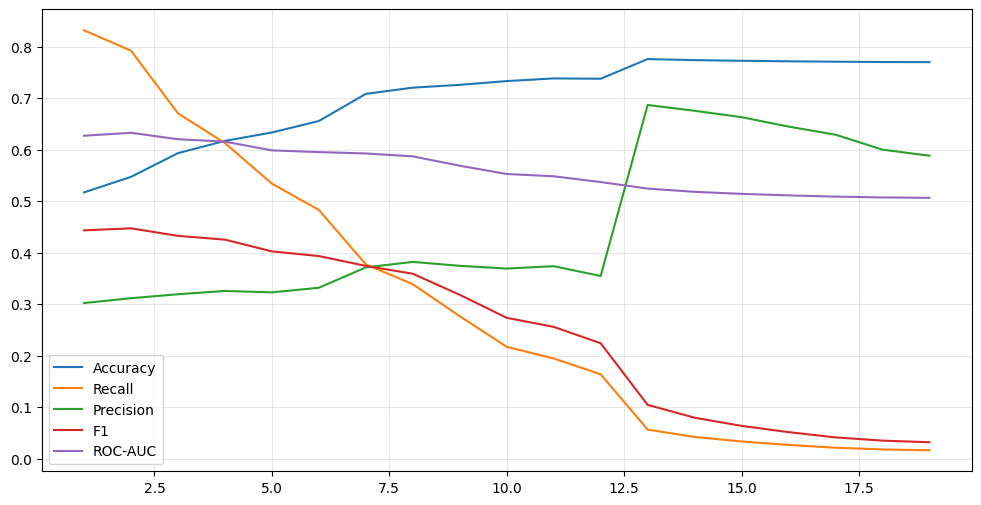

In [27]:
plt.figure(figsize=(12,6))
sns.lineplot(x=list(range(1, 20)), y=accuracy, label='Accuracy')
sns.lineplot(x=list(range(1, 20)), y=recall, label='Recall')
sns.lineplot(x=list(range(1, 20)), y=precision, label='Precision')
sns.lineplot(x=list(range(1, 20)), y=f1, label='F1')
sns.lineplot(x=list(range(1, 20)), y=roc_auc, label='ROC-AUC')
# plt.axhline(y=0.35) 
plt.legend()
plt.grid(alpha=0.3)
plt.show()

As one can see, due to the class imbalance accuracy can achive almost 80% with this very primitve model. At the same time, when switching to another metrics like F1, the results become much worse. For this task I will choose F1 as a metric to maximize, since it combines both risk profiles of a bank (better provide a loan and get a default with some probability or not providing a loan at all, but potentially don't get extra profits if the borrower doesn't default) and hence is more universal for this kind of task. Moreover, F1 helps to take into account class imbalance that we have. As for additional metrics I will use PR-AUC and ROC-AUC

*Logistic regression*

In [28]:
# Now I will use logit with L1 regularization, so firstly the data should be scaled
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Train
scaler = StandardScaler()
columns_to_scale = ['LIMIT_BAL', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'MAX_DELAY',
       'DELAY_STD', 'UNPAID', 'PAY_AMT_RATIO_LAST', 'PAY_AMT_MEAN_RATIO',
       'UTILIZATION_1']
columns_rest = [column for column in X_train.columns if column not in columns_to_scale]
df_scaled = pd.DataFrame(columns=columns_to_scale, data=scaler.fit_transform(X_train[columns_to_scale]))
X_train_scaled = pd.concat([df_scaled, X_train[columns_rest].reset_index(drop=True)], axis=1)
X_train_scaled.head()

,LIMIT_BAL,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,...,PAY_4,PAY_5,PAY_6,ANY_DELAY,SEX_female,MARRIAGE_single,MARRIAGE_other,YOUNG,ADULT,PENSIONER
0,-1.183721,-0.652157,-0.611976,-0.668475,-0.628472,-0.586239,-0.549862,-0.322817,-0.149595,-0.396701,...,0,0,0,0,0,0,0,1,0,0
1,-1.101675,-0.532280,-0.497440,-0.456948,-0.404571,-0.354341,-0.300101,-0.386547,-0.366083,-0.364679,...,0,0,0,1,0,0,1,0,1,0
2,-0.855537,0.014926,0.074825,-0.232873,-0.170624,-0.156601,-0.119056,-0.243945,-0.325568,-0.389185,...,0,0,0,0,0,1,0,1,0,0
3,1.359700,1.673619,1.616713,1.627713,1.598742,1.734244,1.804210,0.151840,0.333636,0.076604,...,0,0,0,0,1,0,0,0,1,0
4,-0.199171,1.441928,1.476450,1.376685,1.114854,0.780487,1.529933,0.213518,0.461209,0.174467,...,0,0,0,0,1,0,0,0,1,0


In [29]:
# Test
df_scaled_test = pd.DataFrame(columns=columns_to_scale, data=scaler.transform(X_test[columns_to_scale]))
X_test_scaled = pd.concat([df_scaled_test, X_test[columns_rest].reset_index(drop=True)], axis=1)
X_test_scaled.head()

,LIMIT_BAL,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,...,PAY_4,PAY_5,PAY_6,ANY_DELAY,SEX_female,MARRIAGE_single,MARRIAGE_other,YOUNG,ADULT,PENSIONER
0,0.949471,0.645221,0.742801,0.875557,1.035858,1.189366,1.285882,-0.165072,0.005039,-0.021096,...,0,0,0,0,1,0,0,0,1,0
1,0.375150,-0.748181,-0.697588,-0.689473,-0.642828,-0.624652,-0.591845,-0.243945,-0.613497,-0.332003,...,2,2,0,1,0,0,0,0,1,0
2,-1.101675,-0.488215,-0.461874,-0.414661,-0.435311,-0.396700,-0.362123,-0.428034,-0.359897,-0.331023,...,0,0,0,0,1,1,0,1,0,0
3,-0.117125,1.288635,1.537551,1.698283,1.928655,2.042455,2.171488,1.096895,0.314307,0.354183,...,2,2,2,1,1,0,0,0,1,0
4,1.031517,1.208718,1.339924,1.599850,1.792703,1.992984,2.128502,0.057508,0.976450,-0.085957,...,0,0,0,0,1,1,0,1,0,0


In [116]:
# Implementing Logistic regression
logit = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
scores = cross_val_score(logit, X_train_scaled, y_train, scoring='f1', cv=5)
scores, scores.mean()

(array([0.4519084 , 0.43969466, 0.44822257, 0.48502994, 0.45026178]),
 np.float64(0.45502346786947534))

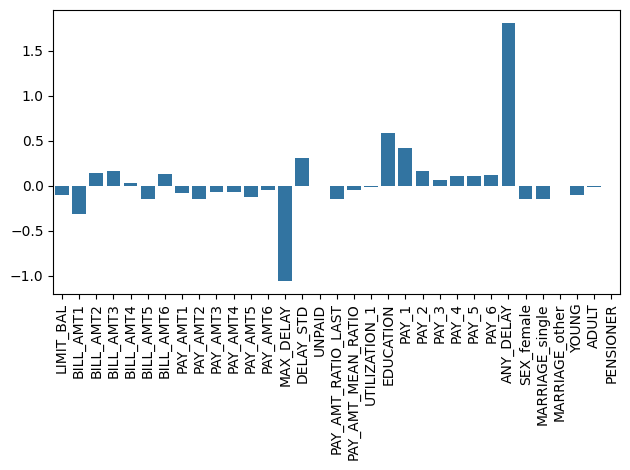

In [117]:
logit.fit(X_train_scaled, y_train)
coef_dict = {name: coef for name, coef in zip(X_train_scaled.columns, logit.coef_[0])}

sns.barplot(x=coef_dict.keys(), y=coef_dict.values())
plt.xticks(rotation=90)
# plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [118]:
predictions = logit.predict(X_test_scaled)
print(f"F1 on test = {f1_score(y_test, predictions)}, ROC-AUC on test = {roc_auc_score(y_test, predictions)}, AP on test = {average_precision_score(y_test, predictions)}")

F1 on test = 0.4683234161708085, ROC-AUC on test = 0.6533693304771628, AP on test = 0.383144221010074


In [ ]:
non_zero_coef_dict = {name: coef for name, coef in zip(X_train_scaled.columns, logit.coef_[0]) if coef != 0}
len(non_zero_coef_dict.keys())

30

In [34]:
from sklearn.feature_selection import f_classif

def evaluate_features_anova(X, y):
    f_scores, p_values = f_classif(X, y)
    results = pd.DataFrame({
        'feature': X.columns,
        'f_score': f_scores,
        'p_value': p_values
    }).sort_values('f_score', ascending=False)
    return results
anova_features = evaluate_features_anova(X_train_scaled, y_train)
anova_features.reset_index(drop=True, inplace=True)
anova_features

,feature,f_score,p_value
0,ANY_DELAY,2790.262447,0.000000e+00
1,MAX_DELAY,2335.233913,0.000000e+00
2,PAY_1,2268.493758,0.000000e+00
3,PAY_2,1433.098935,5.135037e-302
4,DELAY_STD,1279.317626,6.708972e-271
5,PAY_3,1112.297420,7.989397e-237
6,PAY_4,960.188913,1.569278e-205
7,PAY_5,838.216546,2.961096e-180
8,PAY_6,740.335846,7.490658e-160
9,LIMIT_BAL,479.053446,7.537172e-105


In [69]:
from sklearn.model_selection import cross_validate

columns_to_use = anova_features[anova_features['p_value'] <= 0.05].feature.values
logit_selected = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)

scores = cross_validate(logit_selected, X_train_scaled[columns_to_use], y_train, cv=5, scoring=['f1', 'roc_auc', 'average_precision'])
print(f"Mean F1 = {scores['test_f1'].mean()}, mean ROC-AUC = {scores['test_roc_auc'].mean()}, mean PR-AUC = {scores['test_average_precision'].mean()}")

Mean F1 = 0.4531095243342417, mean ROC-AUC = 0.7567720801548061, mean PR-AUC = 0.5257014892342884


In [70]:
logit_selected.fit(X_train_scaled[columns_to_use], y_train)
predictions = logit_selected.predict(X_test_scaled[columns_to_use])
print(f"F1 on test = {f1_score(y_test, predictions)}, ROC-AUC on test = {roc_auc_score(y_test, predictions)}, AP on test = {average_precision_score(y_test, predictions)}")

F1 on test = 0.46678383128295253, ROC-AUC on test = 0.6525735672391938, AP on test = 0.3829792583761701


In [37]:
# Moving to decision tree
# Default hyperparameters
from sklearn.tree import DecisionTreeClassifier
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)
predictions_tree = tree_clf.predict(X_test)
print(f"F1 on test = {f1_score(y_test, predictions_tree)}, ROC-AUC on test = {roc_auc_score(y_test, predictions_tree)}, AP on test = {average_precision_score(y_test, predictions_tree)}")

F1 on test = 0.4176, ROC-AUC on test = 0.6202463856715087, AP on test = 0.3062472176673867


In [39]:
# Optimizing
from sklearn.model_selection import GridSearchCV
tree_clf = DecisionTreeClassifier(random_state=42)
param_grid = {
    'max_depth': [None, 1, 2, 3, 4, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 4, 6, 8, 10, 12, 16, 24, 36, 50],
    'max_features': [0.3, 0.5, 0.8, 'sqrt', 'log2']
}
grid_search = GridSearchCV(
    estimator=tree_clf, 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1',
    n_jobs=-1 
)
grid_search.fit(X_train, y_train)
print(grid_search.best_estimator_)
print(grid_search.best_score_)

DecisionTreeClassifier(max_depth=4, max_features=0.3, min_samples_split=24,
                       random_state=42)
0.4911413005811882


12


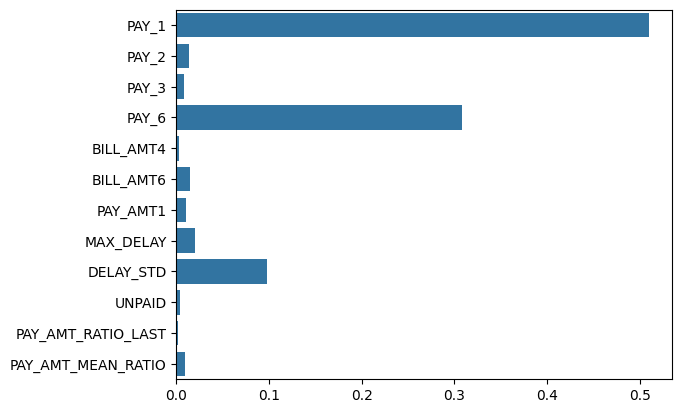

In [40]:
best_tree = grid_search.best_estimator_
print(np.sum(best_tree.feature_importances_ > 0))
important_features = {col: value for col, value in zip(X_train.columns, best_tree.feature_importances_) if value > 0}
sns.barplot(y=important_features.keys(), x=important_features.values())
plt.show()

In [41]:
# Predictions on train
in_sample_predictions = best_tree.predict(X_train)
print(f"F1 on train = {f1_score(y_train, in_sample_predictions)}, ROC-AUC on train = {roc_auc_score(y_train, in_sample_predictions)}, AP on train = {average_precision_score(y_train, in_sample_predictions)}")

# Out-of-sample scores
predictions_best_tree = best_tree.predict(X_test)
print(f"F1 on test = {f1_score(y_test, predictions_best_tree)}, ROC-AUC on test = {roc_auc_score(y_test, predictions_best_tree)}, AP on test = {average_precision_score(y_test, predictions_best_tree)}")

F1 on train = 0.4978953698135899, ROC-AUC on train = 0.6684525251296354, AP on train = 0.4091849650775572
F1 on test = 0.4898102600140548, ROC-AUC on test = 0.664298042947814, AP on test = 0.4025822734600738


More complex models

In [42]:
!pip install catboost -q
from catboost import CatBoostClassifier


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
X_train_cat, X_val_cat, y_train_cat, y_val_cat = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

In [122]:
# Out of the box catboost
cat_model = CatBoostClassifier(loss_function='Logloss', eval_metric='F1', verbose=0)
cat_model.fit(X_train_cat, y_train_cat, eval_set=(X_val_cat, y_val_cat), early_stopping_rounds=50, use_best_model=True)
predictions_catboost = cat_model.predict(X_test)
print(f"F1 on test = {f1_score(y_test, predictions_catboost)}, ROC-AUC on test = {roc_auc_score(y_test, predictions_catboost)}, AP on test = {average_precision_score(y_test, predictions_catboost)}")

F1 on test = 0.48100358422939066, ROC-AUC on test = 0.6596303604868018, AP on test = 0.4007387986322768


Since basic Catboost already gives us decent results, I will use Optuna optimization to search for the optimal hyperparameters.

In [45]:
! pip install optuna -q
import optuna


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
def objective(trial):

  iterations = trial.suggest_int('iterations', 100, 1000, step=100)
  depth = trial.suggest_int('depth', 1, 10, step=1)
  min_data_in_leaf = trial.suggest_categorical('min_data_in_leaf', [1, 5, 10, 20, 30, 40, 50])
  rsm = trial.suggest_categorical('rsm', [0.2, 0.5, 0.7, 0.9, 1])

  model = CatBoostClassifier(iterations=iterations, depth=depth, min_data_in_leaf=min_data_in_leaf, rsm=rsm, random_state=42, loss_function='Logloss')
  scores = cross_val_score(model, X_train, y_train,  cv=3, scoring='f1', n_jobs=-1)

  return scores.mean()

# Creating an Optuna study
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),  # TPE algorithm for the more efficient search
    study_name='Catboost_optimization'
)
n_trials = 30
study.optimize(objective, n_trials=n_trials)

# Optimization results
print(f"Best trial:")
print(f"F1 after optimization: {study.best_trial.value:.4f}")
print(f"Best parameters: {study.best_trial.params}")

[I 2026-06-29 09:56:05,977] A new study created in memory with name: Catboost_optimization
[I 2026-06-29 09:56:34,014] Trial 0 finished with value: 0.47870690870660043 and parameters: {'iterations': 400, 'depth': 10, 'min_data_in_leaf': 40, 'rsm': 0.7}. Best is trial 0 with value: 0.47870690870660043.
[I 2026-06-29 09:56:35,492] Trial 1 finished with value: 0.4836441714386308 and parameters: {'iterations': 200, 'depth': 2, 'min_data_in_leaf': 30, 'rsm': 0.7}. Best is trial 1 with value: 0.4836441714386308.
[I 2026-06-29 09:56:38,766] Trial 2 finished with value: 0.4722141247707968 and parameters: {'iterations': 600, 'depth': 1, 'min_data_in_leaf': 30, 'rsm': 0.5}. Best is trial 1 with value: 0.4836441714386308.
[I 2026-06-29 09:56:44,635] Trial 3 finished with value: 0.4737530514499683 and parameters: {'iterations': 100, 'depth': 10, 'min_data_in_leaf': 50, 'rsm': 0.5}. Best is trial 1 with value: 0.4836441714386308.
[I 2026-06-29 09:56:45,343] Trial 4 finished with value: 0.4859961480

Best trial:
F1 after optimization: 0.4898
Best parameters: {'iterations': 500, 'depth': 5, 'min_data_in_leaf': 10, 'rsm': 0.9}


In [47]:
# cat_model = CatBoostClassifier(**study.best_trial.params, loss_function='Logloss', eval_metric='F1', verbose=1)
# cat_model.fit(X_train_cat, y_train_cat, eval_set=(X_val_cat, y_val_cat), early_stopping_rounds=50, use_best_model=True)
cat_model = CatBoostClassifier(**study.best_trial.params, loss_function='Logloss', verbose=1)
cat_model.fit(X_train, y_train)
predictions_catboost = cat_model.predict(X_test)
print(f"F1 on test = {f1_score(y_test, predictions_catboost)}, ROC-AUC on test = {roc_auc_score(y_test, predictions_catboost)}, AP on test = {average_precision_score(y_test, predictions_catboost)}")

Learning rate set to 0.06736
0:	learn: 0.6561729	total: 4.23ms	remaining: 2.11s
1:	learn: 0.6244661	total: 8.63ms	remaining: 2.15s
2:	learn: 0.5976506	total: 12.6ms	remaining: 2.09s
3:	learn: 0.5748971	total: 19.3ms	remaining: 2.4s
4:	learn: 0.5556885	total: 25ms	remaining: 2.48s
5:	learn: 0.5397186	total: 29.2ms	remaining: 2.41s
6:	learn: 0.5257753	total: 34.1ms	remaining: 2.4s
7:	learn: 0.5138014	total: 38.9ms	remaining: 2.39s
8:	learn: 0.5035792	total: 43.7ms	remaining: 2.38s
9:	learn: 0.4947747	total: 48.8ms	remaining: 2.39s
10:	learn: 0.4873268	total: 54.7ms	remaining: 2.43s
11:	learn: 0.4801033	total: 59ms	remaining: 2.4s
12:	learn: 0.4744985	total: 63.7ms	remaining: 2.39s
13:	learn: 0.4695402	total: 68.8ms	remaining: 2.39s
14:	learn: 0.4657931	total: 73.3ms	remaining: 2.37s
15:	learn: 0.4624783	total: 78.7ms	remaining: 2.38s
16:	learn: 0.4594155	total: 83.7ms	remaining: 2.38s
17:	learn: 0.4566521	total: 88.3ms	remaining: 2.36s
18:	learn: 0.4539608	total: 92.7ms	remaining: 2.35s


In [48]:
print(f"Catboost best params: {cat_model.get_params()}")

Catboost best params: {'iterations': 500, 'depth': 5, 'rsm': 0.9, 'loss_function': 'Logloss', 'verbose': 1, 'min_data_in_leaf': 10}


In [49]:
from sklearn.neural_network import MLPClassifier
# Firstly will try out of the box nueral network
nn_clf = MLPClassifier(random_state=42)
nn_clf.fit(X_train_scaled, y_train)
predictions_nn = nn_clf.predict(X_test_scaled)
print(f"F1 on test = {f1_score(y_test, predictions_nn)}, ROC-AUC on test = {roc_auc_score(y_test, predictions_nn)}, AP on test = {average_precision_score(y_test, predictions_nn)}")

F1 on test = 0.48808713410483323, ROC-AUC on test = 0.6638393147376317, AP on test = 0.39257382717190337


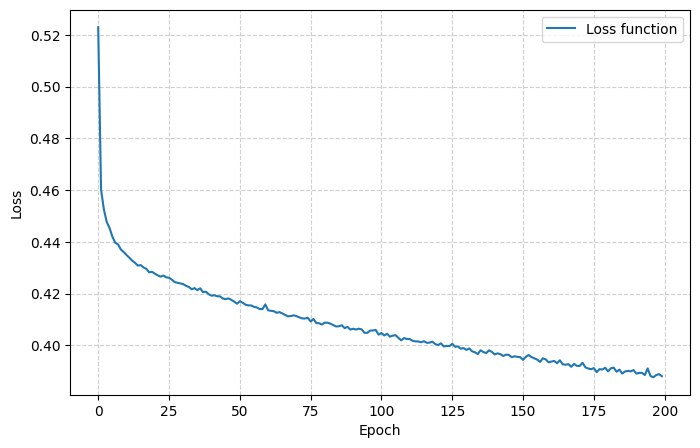

Total number of epochs: 200
Final loss value: 0.3880


In [50]:
plt.figure(figsize=(8, 5))
plt.plot(nn_clf.loss_curve_, label="Loss function")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

print(f"Total number of epochs: {nn_clf.n_iter_}")
print(f"Final loss value: {nn_clf.loss_:.4f}")

In [125]:
# Now I will slightly regularize this neural network
nn_clf = MLPClassifier(hidden_layer_sizes=(2), activation='tanh', alpha=0.001, early_stopping=True, validation_fraction=0.1, n_iter_no_change=10, tol=1e-4,  random_state=42, verbose=False)
nn_clf.fit(X_train_scaled, y_train)
predictions_nn = nn_clf.predict(X_test_scaled)
print(f"Number of iterations = {nn_clf.n_iter_}")
print(f"F1 on test = {f1_score(y_test, predictions_nn)}, ROC-AUC on test = {roc_auc_score(y_test, predictions_nn)}, AP on test = {average_precision_score(y_test, predictions_nn)}")

Number of iterations = 31
F1 on test = 0.5088757396449705, ROC-AUC on test = 0.6756257979712886, AP on test = 0.4020608974290092


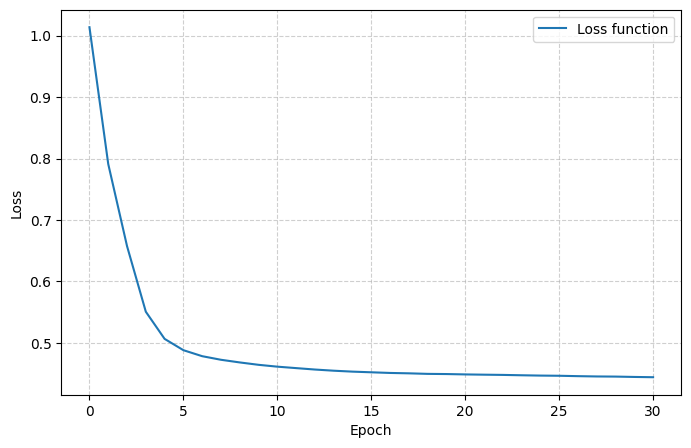

Total number of epochs: 31
Final loss value: 0.4442


In [53]:
plt.figure(figsize=(8, 5))
plt.plot(nn_clf.loss_curve_, label="Loss function")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

print(f"Total number of epochs: {nn_clf.n_iter_}")
print(f"Final loss value: {nn_clf.loss_:.4f}")

Logit: Argmax = 3, max = 0.5360824742268041, best threshold = 0.2
Decision tree: Argmax = 5, max = 0.5424083769633508, best threshold = 0.3
Catboost: Argmax = 5, max = 0.5575620767494357, best threshold = 0.3
NN: Argmax = 4, max = 0.5294748124330118, best threshold = 0.25


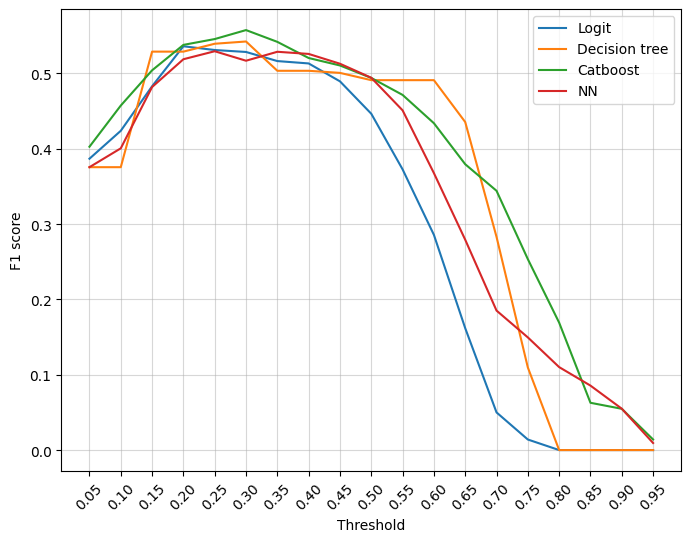

In [126]:
# Adjusting a threshold for all models
from copy import deepcopy

X_train_new, X_val_new, y_train_new, y_val_new = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)
X_train_scaled_new, X_val_scaled_new, y_train_sc_new, y_val_sc_new = train_test_split(X_train_scaled, y_train, test_size=0.1, random_state=42, stratify=y_train)

f1_logit_list = []
f1_tree_list = []
f1_catboost_list = []
f1_nn_list = []

logit_model = deepcopy(logit).fit(X_train_scaled_new, y_train_sc_new)
decision_tree_model = deepcopy(grid_search.best_estimator_).fit(X_train_new, y_train_new)
catboost_model = deepcopy(cat_model).fit(X_train_new, y_train_new)
nn_model = deepcopy(nn_clf).fit(X_train_scaled_new, y_train_sc_new)
for thr in np.arange(0.05, 1, 0.05):
    preds_logit = (logit_model.predict_proba(X_val_scaled_new)[:, 1] > thr).astype(int)
    preds_tree = (decision_tree_model.predict_proba(X_val_new)[:, 1] > thr).astype(int)
    preds_catboost = (catboost_model.predict_proba(X_val_new)[:, 1] > thr).astype(int)
    preds_nn = (nn_model.predict_proba(X_val_scaled_new)[:, 1] > thr).astype(int)
    f1_logit_list.append(f1_score(y_val_sc_new, preds_logit)) 
    f1_tree_list.append(f1_score(y_val_new, preds_tree))
    f1_catboost_list.append(f1_score(y_val_new, preds_catboost))
    f1_nn_list.append(f1_score(y_val_sc_new, preds_nn)) 
print(f"Logit: Argmax = {np.argmax(f1_logit_list)}, max = {np.max(f1_logit_list)}, best threshold = {np.arange(0.05, 1, 0.05)[np.argmax(f1_logit_list)]}")
print(f"Decision tree: Argmax = {np.argmax(f1_tree_list)}, max = {np.max(f1_tree_list)}, best threshold = {np.arange(0.05, 1, 0.05)[np.argmax(f1_tree_list)]}")
print(f"Catboost: Argmax = {np.argmax(f1_catboost_list)}, max = {np.max(f1_catboost_list)}, best threshold = {np.arange(0.05, 1, 0.05)[np.argmax(f1_catboost_list)]}")
print(f"NN: Argmax = {np.argmax(f1_nn_list)}, max = {np.max(f1_nn_list)}, best threshold = {np.arange(0.05, 1, 0.05)[np.argmax(f1_nn_list)]}")

plt.figure(figsize=(8,6))
sns.lineplot(x=np.arange(0.05, 1, 0.05), y=f1_logit_list, label='Logit')
sns.lineplot(x=np.arange(0.05, 1, 0.05), y=f1_tree_list, label='Decision tree')
sns.lineplot(x=np.arange(0.05, 1, 0.05), y=f1_catboost_list, label='Catboost')
sns.lineplot(x=np.arange(0.05, 1, 0.05), y=f1_nn_list, label='NN')
plt.xlabel('Threshold')
plt.xticks(np.arange(0.05, 1, 0.05), rotation=45)
plt.ylabel('F1 score')
plt.grid(alpha=0.5)
plt.show()


In [128]:
# Voting estimator
thresholds = np.arange(0.05, 1, 0.05)
logit_prediction = (logit.predict_proba(X_test_scaled)[:, 1] > thresholds[np.argmax(f1_logit_list)]).astype(int)
tree_prediction = (best_tree.predict_proba(X_test)[:, 1] > thresholds[np.argmax(f1_tree_list)]).astype(int)
catboost_prediction = (cat_model.predict_proba(X_test)[:, 1] > thresholds[np.argmax(f1_catboost_list)]).astype(int)
nn_prediction = (nn_clf.predict_proba(X_test_scaled)[:, 1] > thresholds[np.argmax(f1_nn_list)]).astype(int)

predictions_0 = np.concatenate((logit_prediction.reshape(-1, 1), catboost_prediction.reshape(-1, 1), nn_prediction.reshape(-1, 1)), axis=1)
predictions_1 = np.concatenate((tree_prediction.reshape(-1, 1), catboost_prediction.reshape(-1, 1), nn_prediction.reshape(-1, 1)), axis=1)
predictions_final_0 = np.median(predictions_0, axis=1)
predictions_final_1 = np.median(predictions_1, axis=1)
print(f"(Logit, Catboost, NN): F1 on test = {f1_score(y_test, predictions_final_0)}, ROC-AUC on test = {roc_auc_score(y_test, predictions_final_0)}, AP on test = {average_precision_score(y_test, predictions_final_0)}")
print(f"(Tree, Catboost, NN): F1 on test = {f1_score(y_test, predictions_final_1)}, ROC-AUC on test = {roc_auc_score(y_test, predictions_final_1)}, AP on test = {average_precision_score(y_test, predictions_final_1)}")

(Logit, Catboost, NN): F1 on test = 0.5545752457776657, ROC-AUC on test = 0.7157068794116623, AP on test = 0.40107011536431486
(Tree, Catboost, NN): F1 on test = 0.5584865440980549, ROC-AUC on test = 0.7148138253653208, AP on test = 0.41018749442719066
